# Notebook 43: DistilBERT
**Dataset**: SMS Spam Collection | **Task**: Binary Text Classification (ham/spam)

Dataset: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

In [1]:
import os, warnings, re, string, pickle
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

try:
    import transformers
    print(f"Transformers: {transformers.__version__}")
except ImportError:
    import subprocess
    subprocess.run(["pip","install","transformers","datasets","accelerate","-q"])
    import transformers
    print(f"Transformers: {transformers.__version__}")

import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
print("Libraries ready. Device:", "cuda" if torch.cuda.is_available() else "cpu")


Transformers: 5.0.0
Libraries ready. Device: cuda


In [2]:
MODEL_NAME = "distilbert_finetuned"
OUTPUT_DIR = "/kaggle/working/"
def sp(s): return os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_{s}")

In [3]:
# ── CELL 2: Load & Prepare SMS Spam Dataset ─────────────────────────────
import os
import re
import string
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Configuration
DATA_PATH = "/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset"
TARGET_COLUMN = "v1"
TEXT_COLUMN = "v2"
RANDOM_STATE = 42
TEST_SIZE = 0.20

# Find the CSV file automatically
csv_files = []
for root, dirs, files in os.walk(DATA_PATH):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

if len(csv_files) == 0:
    raise FileNotFoundError(f"No CSV file found in {DATA_PATH}")

print("Using dataset:", csv_files[0])

# Load dataset
df = pd.read_csv(csv_files[0], encoding="latin-1")

# Keep only required columns
df = df[["v1", "v2"]]
df.columns = [TARGET_COLUMN, TEXT_COLUMN]
df.dropna(inplace=True)

print("Dataset shape:", df.shape)
print(df[TARGET_COLUMN].value_counts())

# Text cleaning
def clean(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean"] = df[TEXT_COLUMN].apply(clean)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df[TARGET_COLUMN])

# Train-validation split
X_tr_raw, X_val_raw, y_tr, y_val = train_test_split(
    df["clean"].values,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train samples: {len(X_tr_raw)}")
print(f"Validation samples: {len(X_val_raw)}")

Using dataset: /kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv
Dataset shape: (5572, 2)
v1
ham     4825
spam     747
Name: count, dtype: int64
Train samples: 4457
Validation samples: 1115


Loading distilbert-base-uncased...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model on: cuda
Epoch 1 | Train Loss: 0.1379 | Val Acc: 0.9865
Epoch 2 | Train Loss: 0.0319 | Val Acc: 0.9874
Epoch 3 | Train Loss: 0.0211 | Val Acc: 0.9865


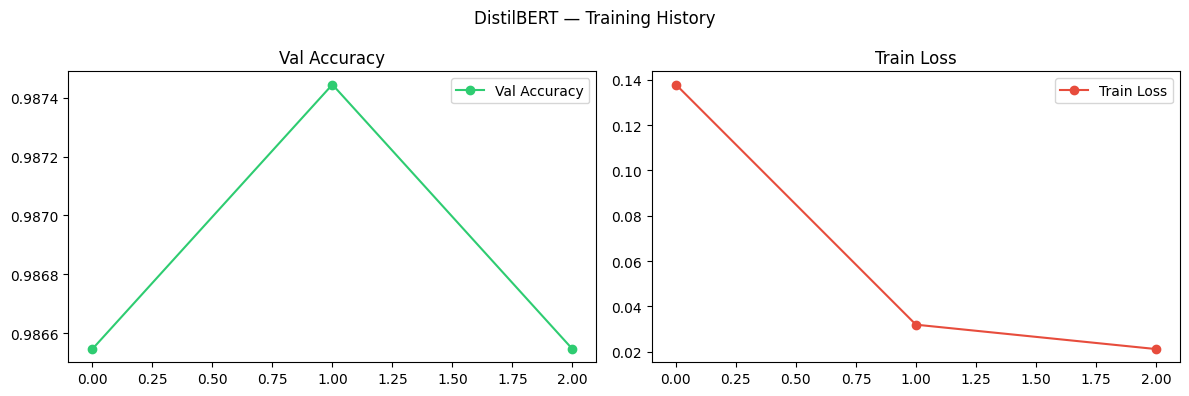

Final Val Accuracy: 0.9865  ROC-AUC: 0.9942
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.95      0.95      0.95       149

    accuracy                           0.99      1115
   macro avg       0.97      0.97      0.97      1115
weighted avg       0.99      0.99      0.99      1115



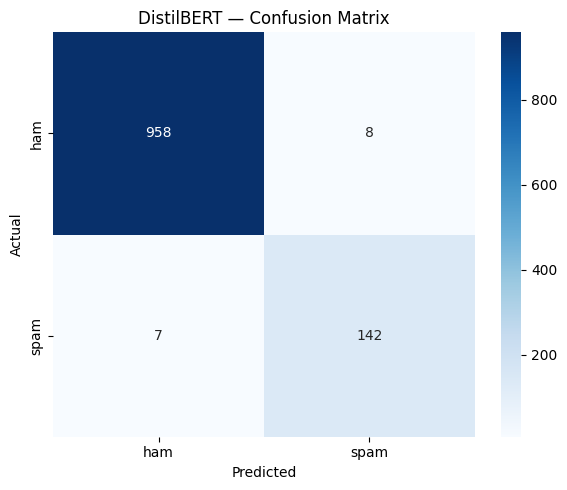

In [4]:
# ── Load DistilBERT for Sequence Classification ─────────────
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from torch.utils.data import Dataset

MODEL_ID = "distilbert-base-uncased"
print(f"Loading {MODEL_ID}...")
hf_tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
hf_model     = AutoModelForSequenceClassification.from_pretrained(MODEL_ID, num_labels=2)
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
hf_model.to(DEVICE); print(f"Model on: {DEVICE}")

# Dataset class
class SMSDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.enc    = tokenizer(list(texts), truncation=True, padding="max_length",
                                max_length=max_len, return_tensors="pt")
        self.labels = torch.tensor(labels).long()
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return {k: v[i] for k,v in self.enc.items()}, self.labels[i]

tr_ds  = SMSDataset(X_tr_raw, y_tr,  hf_tokenizer)
val_ds = SMSDataset(X_val_raw, y_val, hf_tokenizer)

from torch.utils.data import DataLoader
import torch.optim as optim

tr_loader  = DataLoader(tr_ds,  batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

EPOCHS = 3
optimizer = optim.AdamW(hf_model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.1, total_iters=len(tr_loader)*EPOCHS)

train_losses, val_accs = [], []
for epoch in range(EPOCHS):
    hf_model.train()
    ep_loss = 0
    for batch, labels in tr_loader:
        batch   = {k: v.to(DEVICE) for k,v in batch.items()}
        labels  = labels.to(DEVICE)
        optimizer.zero_grad()
        out     = hf_model(**batch, labels=labels)
        loss    = out.loss
        loss.backward(); optimizer.step(); scheduler.step()
        ep_loss += loss.item()
    train_losses.append(ep_loss / len(tr_loader))

    hf_model.eval(); correct = total = 0
    with torch.no_grad():
        for batch, labels in val_loader:
            batch = {k: v.to(DEVICE) for k,v in batch.items()}
            preds = hf_model(**batch).logits.argmax(dim=-1).cpu()
            correct += (preds == labels).sum().item(); total += len(labels)
    val_acc = correct / total
    val_accs.append(val_acc)
    print(f"Epoch {epoch+1} | Train Loss: {train_losses[-1]:.4f} | Val Acc: {val_acc:.4f}")

# Training plot
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(val_accs,    label="Val Accuracy", marker="o", color="#2ecc71")
axes[0].set_title("Val Accuracy"); axes[0].legend()
axes[1].plot(train_losses,label="Train Loss",   marker="o", color="#e74c3c")
axes[1].set_title("Train Loss"); axes[1].legend()
plt.suptitle(f"DistilBERT — Training History")
plt.tight_layout(); plt.savefig(sp("training_history.png"),bbox_inches="tight"); plt.show()

# Evaluate
hf_model.eval(); all_preds, all_probs = [], []
with torch.no_grad():
    for batch, labels in val_loader:
        batch    = {k: v.to(DEVICE) for k,v in batch.items()}
        logits   = hf_model(**batch).logits.cpu()
        probs    = torch.softmax(logits, dim=-1)[:,1].numpy()
        preds    = logits.argmax(dim=-1).numpy()
        all_preds.extend(preds); all_probs.extend(probs)

y_pred_cls = np.array(all_preds)
y_pred_prob= np.array(all_probs)
roc  = roc_auc_score(y_val, y_pred_prob)
acc  = accuracy_score(y_val, y_pred_cls)
METRICS = dict(Model=MODEL_NAME, Val_Accuracy=round(acc,4), ROC_AUC=round(roc,4))
print(f"Final Val Accuracy: {acc:.4f}  ROC-AUC: {roc:.4f}")
print(classification_report(y_val, y_pred_cls, target_names=le.classes_, zero_division=0))

cm = confusion_matrix(y_val, y_pred_cls)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"DistilBERT — Confusion Matrix")
plt.tight_layout(); plt.savefig(sp("confusion_matrix.png"),bbox_inches="tight"); plt.show()
model = hf_model


In [5]:
import glob
torch.save(hf_model.state_dict(), sp("model.pt"))
pd.DataFrame([METRICS]).to_csv(sp("metrics.csv"), index=False)
pd.DataFrame({"y_true": y_val, "y_pred": y_pred_cls}).to_csv(sp("predictions.csv"), index=False)
for f in sorted(glob.glob(f"/kaggle/working/{MODEL_NAME}_*")): print(f"  {os.path.basename(f)}")


  distilbert_finetuned_confusion_matrix.png
  distilbert_finetuned_metrics.csv
  distilbert_finetuned_model.pt
  distilbert_finetuned_predictions.csv
  distilbert_finetuned_training_history.png


In [6]:
print("="*60); print(f"  NOTEBOOK 43 COMPLETE — DISTILBERT"); print("="*60)
for k,v in METRICS.items(): print(f"  {k}: {v}")
print("="*60)


  NOTEBOOK 43 COMPLETE — DISTILBERT
  Model: distilbert_finetuned
  Val_Accuracy: 0.9865
  ROC_AUC: 0.9942
